# Full-resolution comparison ($N_t = 150$)

Section 3.3 (*DL-ROM Baseline Results*) and the synthesis table of Section 4.1. DL-ROM, SLAE and LLAE at the common operating point, evaluated on the native time grid without interpolation, and benchmarked in a single run so the cost figures are mutually comparable.


In [1]:
import sys, os
os.environ.setdefault('PYTORCH_CUDA_ALLOC_CONF', 'expandable_segments:True')
sys.path.insert(0, os.path.join('..', 'src'))

import glob
import re
import gc
import numpy as np
import torch
import torch.nn.functional as F_nn
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from matplotlib.lines import Line2D
from tqdm.auto import tqdm

from laplace_surrogate.inference.pipeline import InferencePipeline

/users/eleves-b/2023/keyvan.attarian/diffusion_ae/.venv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Article figure style; `run` prefixes the output filenames.
import figstyle
figstyle.setup(run='dlrom')       # titles=True pour garder les suptitle en interactif


figstyle: style=paper.mplstyle  run=dlrom  titles=suppressed  ->  /users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images


## 1. Configuration

DL-ROM sweep resolutions and Laplace reference checkpoints. All listed `K=16` variants are included: `_ll` (LLAE, learnable poles), `_ol` (SLAE, offline contour) and the prescribed-contour baseline.


In [3]:
# DL-ROM emits only its native Nt, so the sweep needs one checkpoint per point.
NT_LIST   = [150, 75, 50, 30, 15]          # available DL-ROM checkpoints
NT_FULL   = 150                            # native number of time steps

# Output resolutions for the cost-versus-Nt sweep. The Laplace pipelines emit
# any Nt from a single
#    checkpoint K=16 (predict(..., n_frames=Nt) / generate(Nt=...)) — horizon T conservé.
NT_GRID   = [15, 30, 50, 75, 150]

# Laplace references: every listed variant is included.
#   _ll = learnable poles (LLAE, g0.0); _ol = offline contour (SLAE, g0.0);
#   no suffix = prescribed contour (g0.01).
LLAE_REFS = [
    'LLAEModel__llae_ld64_K16_g0.0_ll__t*',
    'LLAEModel__llae_ld64_K16_g0.01__t*',
]
SLAE_REFS = [
    'SLAEModel__slae_ld64_K16_g0.0_ol__t*',
    'SLAEModel__slae_ld64_K16_g0.01__t*',
]

POD_REF_MEDIAN = 8.91      # median relative L2 error (%) of the best POD surrogate

DATA_PATH  = '../dataset/ch4_rotated.npy'
DOE_PATH   = '../dataset/doe_rotated.npy'
SPLIT_PATH = '../dataset/split.npz'
CKPT_DIR   = '../checkpoints'
CACHE_DIR  = 'cache_dlrom'
N          = 128
DT         = 1.0

os.makedirs(CACHE_DIR, exist_ok=True)
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## 2. Dataset


In [4]:
# Raw field data (mmap)
U_raw = np.load(DATA_PATH, mmap_mode='r')          # (ns, Nt, H, W)
ns, Nt_full, H, W = U_raw.shape
print(f'Dataset: {ns} sims, Nt={Nt_full}, {H}×{W}')
assert Nt_full == NT_FULL, f'Attendu Nt={NT_FULL}, trouvé {Nt_full}'

# Physical parameters θ = (k, A, C)
doe = np.load(DOE_PATH)
theta_np = np.stack([doe['k'], doe['A'], doe['C']], axis=1).astype(np.float32)  # (ns, 3)
print(f'θ shape: {theta_np.shape}  min={theta_np.min():.3f}  max={theta_np.max():.3f}')

# Train/test split
split     = np.load(SPLIT_PATH)
test_idx  = split['test_idx'].tolist()
train_idx = [i for i in range(ns) if i not in set(test_idx)]
print(f'Train: {len(train_idx)}  Test: {len(test_idx)}')

Dataset: 8100 sims, Nt=150, 128×128
θ shape: (8100, 3)  min=0.000  max=350.000


Train: 6480  Test: 1620


In [5]:
def load_u(idx: int) -> np.ndarray:
    '''Load and resize U to (Nt, N, N) float32 (full 150-step horizon).'''
    u = U_raw[idx].astype(np.float32)
    if u.shape[-1] != N:
        u_t = torch.from_numpy(u).unsqueeze(1)
        u_t = F_nn.interpolate(u_t, size=(N, N), mode='bilinear', align_corners=False)
        u   = u_t.squeeze(1).numpy()
    return u

## 3. Checkpoint discovery

Naming conventions (`.pt` or `.ckpt`):

- DL-ROM: `DLROMModel__dlrom_ld64_Nt{Nt}__t*`, $N_t \in \{150,75,50,30,15\}$
- LLAE: `llae_ld64_K16` — `g0.0_ll` (learnable poles) and `g0.01` (prescribed)
- SLAE: `slae_ld64_K16` — `g0.0_ol` (offline contour) and `g0.01` (prescribed)

Missing patterns are logged and skipped.


In [6]:
def _glob_both(stem_pattern: str) -> list:
    '''Glob a stem pattern over both .pt and .ckpt, sorted.'''
    hits = []
    for ext in ('.pt', '.ckpt'):
        hits += glob.glob(os.path.join(CKPT_DIR, stem_pattern + ext))
    return sorted(set(hits))


def _collect_refs(patterns: list, label: str) -> list:
    '''Return every existing checkpoint among the listed patterns, deduplicated and
    in pattern order. Missing patterns are logged and skipped.'''
    found, seen = [], set()
    for pat in patterns:
        hits = _glob_both(pat)
        if hits:
            for h in hits:                       # tous les hits (ex. -v1, -v2)
                if h not in seen:
                    seen.add(h); found.append(h)
                    print(f'  [{label}] retenu   : {os.path.basename(h)}')
        else:
            print(f'  [{label}] absent   : {pat}(.pt|.ckpt)')
    if not found:
        print(f'  [{label}] AUCUNE référence trouvée → famille ignorée dans les figures.')
    return found


# ── DL-ROM sweep ─────────────────────────────────────────────────────────────
print('DL-ROM sweep :')
dlrom_paths = {}    # Nt_nominal → path
for nt in NT_LIST:
    hits = _glob_both(f'DLROMModel__dlrom_ld64_Nt{nt}__t*')
    if hits:
        dlrom_paths[nt] = hits[-1]
        print(f'  [Nt={nt:>3}] {os.path.basename(hits[-1])}')
    else:
        print(f'  [Nt={nt:>3}] absent   : DLROMModel__dlrom_ld64_Nt{nt}__t*(.pt|.ckpt)')

# ── Références Laplace (toutes les variantes listées) ────────────────────────
print('\nRéférences Laplace :')
llae_refs = _collect_refs(LLAE_REFS, 'LLAE')
slae_refs = _collect_refs(SLAE_REFS, 'SLAE')

# ── Table de travail : name → path (ordre : DL-ROM par Nt ↓, puis réfs) ──────
ckpt_paths = {}
for nt in sorted(dlrom_paths, reverse=True):
    p = dlrom_paths[nt]
    ckpt_paths[os.path.splitext(os.path.basename(p))[0]] = p
for p in (*llae_refs, *slae_refs):
    ckpt_paths[os.path.splitext(os.path.basename(p))[0]] = p

print(f'\n{len(ckpt_paths)} checkpoint(s) à évaluer :')
for n in ckpt_paths:
    print('  ', n)
if not ckpt_paths:
    print('\n*** Aucun checkpoint surrogate trouvé. '
          'Ce notebook doit tourner sur le host GPU distant (voir préconditions). ***')

DL-ROM sweep :
  [Nt=150] DLROMModel__dlrom_ld64_Nt150__t4h2.ckpt
  [Nt= 75] DLROMModel__dlrom_ld64_Nt75__t4h2.ckpt
  [Nt= 50] DLROMModel__dlrom_ld64_Nt50__t4h2.ckpt
  [Nt= 30] DLROMModel__dlrom_ld64_Nt30__t4h2.ckpt
  [Nt= 15] DLROMModel__dlrom_ld64_Nt15__t4h2.ckpt

Références Laplace :
  [LLAE] retenu   : LLAEModel__llae_ld64_K16_g0.0_ll__t4h2.ckpt
  [LLAE] retenu   : LLAEModel__llae_ld64_K16_g0.01__t4h2.ckpt
  [SLAE] retenu   : SLAEModel__slae_ld64_K16_g0.0_ol__t4h2.ckpt
  [SLAE] retenu   : SLAEModel__slae_ld64_K16_g0.01__t4h2.ckpt

9 checkpoint(s) à évaluer :
   DLROMModel__dlrom_ld64_Nt150__t4h2
   DLROMModel__dlrom_ld64_Nt75__t4h2
   DLROMModel__dlrom_ld64_Nt50__t4h2
   DLROMModel__dlrom_ld64_Nt30__t4h2
   DLROMModel__dlrom_ld64_Nt15__t4h2
   LLAEModel__llae_ld64_K16_g0.0_ll__t4h2
   LLAEModel__llae_ld64_K16_g0.01__t4h2
   SLAEModel__slae_ld64_K16_g0.0_ol__t4h2
   SLAEModel__slae_ld64_K16_g0.01__t4h2


## 4. Palette and labels

Shared palette from `figstyle`, plus a colormap indexed by $N_t$ for the DL-ROM sweep.


In [7]:
PALETTE = dict(figstyle.MODEL_COLORS)   # palette partagee — voir notebooks/figstyle.py

# Colormap indexed by Nt for the DL-ROM sweep (small Nt = low cost = light).
DLROM_CMAP = plt.get_cmap('viridis')

def dlrom_color(nt_eff: int, nt_list=None) -> tuple:
    '''Couleur d'un point DL-ROM selon son Nt effectif (léger→foncé).'''
    nts = sorted(nt_list or NT_LIST)
    frac = (nts.index(nt_eff) / max(len(nts) - 1, 1)) if nt_eff in nts else 0.5
    return DLROM_CMAP(0.15 + 0.7 * frac)


# AE stem Laplace, e.g. 'llae_ld64_K16_g0.1_ll' / 'slae_ld64_K16_g0.1_ol'
_AE_STEM_PAT = re.compile(
    r'^(?P<ae>slae|llae|lslae)_ld(?P<ld>\d+)_K(?P<K>\d+)_g(?P<g>[0-9.]+)(?P<ae_suf>.*)$'
)
# AE stem DL-ROM, e.g. 'dlrom_ld64_Nt75'
_AE_STEM_DLROM_PAT = re.compile(r'^dlrom_ld(?P<ld>\d+)_Nt(?P<Nt>\d+)$')

# Surrogate ckpt, e.g. 'DLROMModel__dlrom_ld64_Nt75__t4h2' or
# 'LLAEModel__llae_ld64_K16_g0.1_ll__t4h2[-v1]'
_SURR_PAT = re.compile(
    r'^(?P<cls>[A-Za-z]+Model)__(?P<ae_stem>.+?)__'
    r't(?P<n_trunk>\d+)h(?P<n_head>\d+)(?P<suffix>.*?)(?:-v(?P<ver>\d+))?$'
)


def _fmt_g(g: str) -> str:
    f = float(g)
    return str(int(f)) if f == int(f) else str(f)


def _pretty_name(name: str) -> str:
    '''Nom lisible sur deux lignes. Gère DL-ROM (dlrom_ld*_Nt*) et Laplace.'''
    m = _SURR_PAT.match(name)
    if not m:
        return name
    ae_stem = m.group('ae_stem')

    # ── DL-ROM ───────────────────────────────────────────────────────────────
    dm = _AE_STEM_DLROM_PAT.match(ae_stem)
    if dm:
        nt = int(dm.group('Nt'))
        return (f"DL-ROM  d={dm.group('ld')}, Nt={nt}\n"
                f"t{m.group('n_trunk')}h{m.group('n_head')}  ({nt} têtes)")

    # ── Laplace (SLAE / LLAE) ────────────────────────────────────────────────
    sm = _AE_STEM_PAT.match(ae_stem)
    if not sm:
        return name
    cls   = m.group('cls')
    label = 'LLAE' if cls.startswith('LLAE') else 'SLAE'
    head   = f"{label}  d={sm.group('ld')}, K={sm.group('K')}"
    ae_suf = sm.group('ae_suf').strip('_')
    head  += f' [{ae_suf}]' if ae_suf else f", γ={_fmt_g(sm.group('g'))}"
    return head + '\n' + f"t{m.group('n_trunk')}h{m.group('n_head')}"


def _family(model_type: str) -> str:
    return {'DLROMModel': 'DL-ROM', 'LLAEModel': 'LLAE', 'SLAEModel': 'SLAE'}.get(
        model_type, model_type)



# ── Style commun des figures (marqueur/couleur/label, EN) ────────────────────
def _laplace_basis(name):
    m  = _SURR_PAT.match(name)
    sm = _AE_STEM_PAT.match(m.group('ae_stem')) if m else None
    suf = sm.group('ae_suf').strip('_') if sm else ''
    if suf == 'll': return 'learned', 'learned poles'
    if suf == 'ol': return 'learned', 'optimized contour'
    return 'fixed', 'fixed contour'

def _mk(name):
    r = results[name]; mt = r['model_type']; c = PALETTE.get(mt, 'gray')
    if mt == 'DLROMModel':
        return dict(c=c, marker='o', size=110, face=c, edge='k', lw=0.8,
                    tag=f"DL-ROM $N_t$={r['Nt_eff']}")
    basis, bl = _laplace_basis(name); fam = _family(mt)
    if basis == 'learned':
        return dict(c=c, marker='*', size=340, face=c, edge='k', lw=0.9, tag=f"{fam} ({bl})")
    return dict(c=c, marker='D', size=150, face='white', edge=c, lw=1.8, tag=f"{fam} ({bl})")

def _legend_handle(name):
    m = _mk(name)
    return Line2D([0], [0], marker=m['marker'], color='w',
                  markerfacecolor=(m['face'] if m['face'] != 'white' else 'white'),
                  markeredgecolor=m['edge'], markeredgewidth=m['lw'],
                  markersize=13 if m['marker'] == '*' else 8, label=m['tag'])

def _pointwise_names(src):
    """DL-ROM Nt=150 uniquement + toutes les réfs Laplace."""
    return [n for n in src
            if results[n]['model_type'] != 'DLROMModel' or results[n]['Nt_eff'] == NT_FULL]


## 5. Evaluation — native-grid metric

Each checkpoint is read with its own temporal stride $\kappa$, and predictions are compared against the ground truth subsampled on the same grid, without interpolation. DL-ROM is therefore judged on its $N_{t,\mathrm{eff}}$ steps and the Laplace pipelines ($\kappa = 1$) on all 150.

A second metric, obtained by interpolating a coarse output back to 150 steps, is still computed and cached for format compatibility but is not used: output resolution is carried by the $N_t$ column, not by the metric.


In [8]:
def resample_to_horizon(U_pred: np.ndarray, kappa: int, n_full: int = NT_FULL) -> np.ndarray:
    '''Resample (Nt_eff, N, N) to (n_full, N, N) by linear interpolation in time at the
    sampled positions np.arange(0, n_full, kappa), holding the last value beyond the
    final sample.'''
    if kappa == 1:
        return U_pred                                   # déjà 150 pas (Laplace / DL-ROM-150)
    sample_t = np.arange(0, n_full, kappa)              # (Nt_eff,)  ex. κ=10 → [0,10,…,140]
    assert U_pred.shape[0] == len(sample_t), (
        f'Nt_eff={U_pred.shape[0]} incohérent avec arange(0,{n_full},{kappa})={len(sample_t)}')
    target_t = np.arange(n_full)                        # 0..149
    idx = np.clip(np.searchsorted(sample_t, target_t, side='right') - 1,
                  0, len(sample_t) - 2)                 # segment [idx, idx+1]
    t0, t1 = sample_t[idx], sample_t[idx + 1]
    w = np.clip((target_t - t0) / (t1 - t0), 0.0, 1.0)  # >1 hors-borne → tenue (clip à 1)
    U0, U1 = U_pred[idx], U_pred[idx + 1]
    return U0 + (U1 - U0) * w[:, None, None]


def _l2rel(a: np.ndarray, b: np.ndarray) -> float:
    denom = np.linalg.norm(b)
    return float(np.linalg.norm(a - b) / denom * 100.0) if denom >= 1e-12 else np.nan


def _cost_meta(ckpt_path: str) -> dict:
    '''Cost metadata for a checkpoint, without any forward pass: loads the model on CPU
    and reads κ, Nt_eff, n_heads, n_surr and model_type.'''
    pipe   = InferencePipeline.from_checkpoint(ckpt_path, device='cpu')
    kappa  = int(pipe.ckpt.get('t_stride', 1))
    n_surr = int(sum(p.numel() for p in pipe.model.surrogate.parameters()))
    n_head = int(getattr(pipe.model.surrogate, 'K', pipe.ckpt.get('Nt', NT_FULL)))
    Nt_eff = int(pipe.ckpt.get('Nt', NT_FULL))
    mtype  = pipe.model_type
    pipe.model.cpu(); del pipe; gc.collect()
    return dict(kappa=kappa, Nt_eff=Nt_eff, n_heads=n_head, n_surr=n_surr, model_type=mtype)


def eval_from_l2rel(ckpt_path: str, l2rel: np.ndarray) -> dict:
    '''Résultat pour un modèle Laplace (κ=1) à partir d'un l2rel déjà calculé
    (cache_surr) : l2_grid = l2_horizon = l2rel — car κ=1 ⇒ pas de sous-échantillonnage
    ni de ré-interpolation, donc _l2rel(U_pred, U_full[::1]) == _l2rel(U_pred, U_full).
    Métadonnées via _cost_meta (chargement CPU seul, AUCUN forward sur le test set).'''
    meta = _cost_meta(ckpt_path)
    assert meta['kappa'] == 1, 'réutilisation cache_surr réservée aux modèles Laplace κ=1'
    l2 = np.asarray(l2rel, dtype=np.float64)
    return dict(l2_grid=l2, l2_horizon=l2.copy(), **meta)


def eval_dlrom(ckpt_path: str, idx_list: list, device='cpu', batch_size: int = 32) -> dict:
    '''Evaluate a checkpoint. Returns dict(l2_grid, l2_horizon, kappa, Nt_eff, n_heads,
    n_surr, model_type).'''
    pipe  = InferencePipeline.from_checkpoint(ckpt_path, device=device)
    name  = os.path.basename(ckpt_path)
    kappa = int(pipe.ckpt.get('t_stride', 1))
    mtype = pipe.model_type
    # Surrogate MLP parameters only: N_surr = N_trunk + K*N_head.
    n_surr  = int(sum(p.numel() for p in pipe.model.surrogate.parameters()))
    n_heads = int(getattr(pipe.model.surrogate, 'K', pipe.ckpt.get('Nt', NT_FULL)))

    l2_grid, l2_horizon = [], []
    for start in tqdm(range(0, len(idx_list), batch_size), desc=name, leave=False):
        batch_idx   = idx_list[start:start + batch_size]
        theta_batch = theta_np[batch_idx]              # (B, 3)
        U_pred = pipe.predict(theta_batch)             # (B, Nt_eff, N, N)
        for j, idx in enumerate(batch_idx):
            U_full = load_u(idx)                       # (150, N, N)
            # Native grid: ground truth subsampled onto the model's own time grid.
            l2_grid.append(_l2rel(U_pred[j], U_full[::kappa]))
            # (b) iso-horizon : prédiction ré-interpolée à 150 pas vs champ plein
            l2_horizon.append(_l2rel(resample_to_horizon(U_pred[j], kappa), U_full))
        if device == 'cuda':
            torch.cuda.empty_cache()

    Nt_eff = int(pipe.ckpt.get('Nt', U_pred.shape[1]))
    pipe.model.cpu(); del pipe
    if device == 'cuda':
        torch.cuda.empty_cache()
    gc.collect()
    return dict(
        l2_grid    = np.array(l2_grid),
        l2_horizon = np.array(l2_horizon),
        kappa      = kappa,
        Nt_eff     = Nt_eff,
        n_heads    = n_heads,
        n_surr     = n_surr,
        model_type = mtype,
    )

## 6. Evaluation of all checkpoints

Per-checkpoint cache invalidated on checkpoint mtime. For a Laplace reference ($\kappa = 1$) the surrogate cache already holds the same quantity, so it is reused and only the cost metadata is reloaded; everything else is computed on the GPU.


In [9]:
SURR_CACHE_DIR = 'cache_surr'   # surrogate-notebook cache, reused when available

def _cache_path(name: str) -> str:
    return os.path.join(CACHE_DIR, f'{name}.npz')

def _cache_valid(cache_file: str, ckpt_path: str) -> bool:
    if not os.path.exists(cache_file):
        return False
    try:
        data = np.load(cache_file, allow_pickle=True)
        return float(data['ckpt_mtime']) == os.path.getmtime(ckpt_path)
    except Exception as e:
        print(f'Failed to load cache {cache_file}: {e}')
        return False

def _surr_l2rel(name: str, ckpt_path: str):
    '''Relative error from the surrogate cache if present and current, else None.
    For a Laplace model at κ=1 this equals both grid and horizon metrics.'''
    f = os.path.join(SURR_CACHE_DIR, f'{name}.npz')
    if not os.path.exists(f):
        return None
    try:
        d = np.load(f, allow_pickle=True)
        if float(d['ckpt_mtime']) != os.path.getmtime(ckpt_path):
            return None
        return d['l2rel']
    except Exception:
        return None

def _save_cache(name: str, ckpt_path: str, r: dict):
    np.savez(
        _cache_path(name),
        l2_grid    = r['l2_grid'],
        l2_horizon = r['l2_horizon'],
        kappa      = np.int64(r['kappa']),
        Nt_eff     = np.int64(r['Nt_eff']),
        n_heads    = np.int64(r['n_heads']),
        n_surr     = np.int64(r['n_surr']),
        model_type = str(r['model_type']),
        ckpt_mtime = np.float64(os.path.getmtime(ckpt_path)),
    )

def _load_cache(name: str) -> dict:
    d = np.load(_cache_path(name), allow_pickle=True)
    return dict(
        l2_grid    = d['l2_grid'],
        l2_horizon = d['l2_horizon'],
        kappa      = int(d['kappa']),
        Nt_eff     = int(d['Nt_eff']),
        n_heads    = int(d['n_heads']),
        n_surr     = int(d['n_surr']),
        model_type = str(d['model_type']),
    )


# Order of preference: own cache, then the surrogate cache for Laplace
# references, then a full GPU evaluation.
results = {}   # name → dict (voir eval_dlrom)

for name, ckpt_path in ckpt_paths.items():
    cache_file = _cache_path(name)
    if _cache_valid(cache_file, ckpt_path):
        r = _load_cache(name)
        print(f'[cache]   {name}  [{r["model_type"]}]')
    else:
        # Reuse the surrogate cache for Laplace references only: at κ>1 the two
        # metrics differ and are not stored there.
        l2r = None if name.startswith('DLROMModel') else _surr_l2rel(name, ckpt_path)
        if l2r is not None:
            print(f'[reuse cache_surr] {name}')
            try:
                r = eval_from_l2rel(ckpt_path, l2r)   # aucun forward sur le test set
                _save_cache(name, ckpt_path, r)
            except Exception as e:
                print(f'   reuse KO ({e}) → recalcul GPU'); l2r = None
        if l2r is None:
            print(f'[compute] {name}')
            try:
                r = eval_dlrom(ckpt_path, test_idx, device=device)
                _save_cache(name, ckpt_path, r)
            except Exception as e:
                print(f'   ERROR: {e}')
                continue
    results[name] = r
    g, h = r['l2_grid'], r['l2_horizon']
    print(f'   κ={r["kappa"]:>2}  Nt_eff={r["Nt_eff"]:>3}  heads={r["n_heads"]:>3}  '
          f'N_surr={r["n_surr"]/1e6:5.2f}M  |  '
          f'iso-grille med={np.nanmedian(g):5.2f}% p90={np.nanpercentile(g,90):5.2f}%  |  '
          f'iso-horizon med={np.nanmedian(h):5.2f}% p90={np.nanpercentile(h,90):5.2f}%')

print(f'\nDone. {len(results)} checkpoint(s) évalué(s).')

[cache]   DLROMModel__dlrom_ld64_Nt150__t4h2  [DLROMModel]
   κ= 1  Nt_eff=150  heads=150  N_surr=23.50M  |  iso-grille med= 3.80% p90= 6.12%  |  iso-horizon med= 3.80% p90= 6.12%
[cache]   DLROMModel__dlrom_ld64_Nt75__t4h2  [DLROMModel]
   κ= 2  Nt_eff= 75  heads= 75  N_surr=12.15M  |  iso-grille med= 3.97% p90= 6.40%  |  iso-horizon med= 5.25% p90= 6.93%
[cache]   DLROMModel__dlrom_ld64_Nt50__t4h2  [DLROMModel]
   κ= 3  Nt_eff= 50  heads= 50  N_surr= 8.36M  |  iso-grille med= 3.84% p90= 6.19%  |  iso-horizon med= 6.77% p90= 7.87%
[cache]   DLROMModel__dlrom_ld64_Nt30__t4h2  [DLROMModel]
   κ= 5  Nt_eff= 30  heads= 30  N_surr= 5.33M  |  iso-grille med= 3.86% p90= 6.30%  |  iso-horizon med= 9.32% p90=10.54%
[cache]   DLROMModel__dlrom_ld64_Nt15__t4h2  [DLROMModel]
   κ=10  Nt_eff= 15  heads= 15  N_surr= 3.06M  |  iso-grille med= 3.73% p90= 5.98%  |  iso-horizon med=14.57% p90=16.70%
[cache]   LLAEModel__llae_ld64_K16_g0.0_ll__t4h2  [LLAEModel]
   κ= 1  Nt_eff=150  heads= 16  N_surr= 3.

## 7. DL-ROM at $N_t = 150$ — relative $L^2$ error


[cache]   DL-ROM AE recon


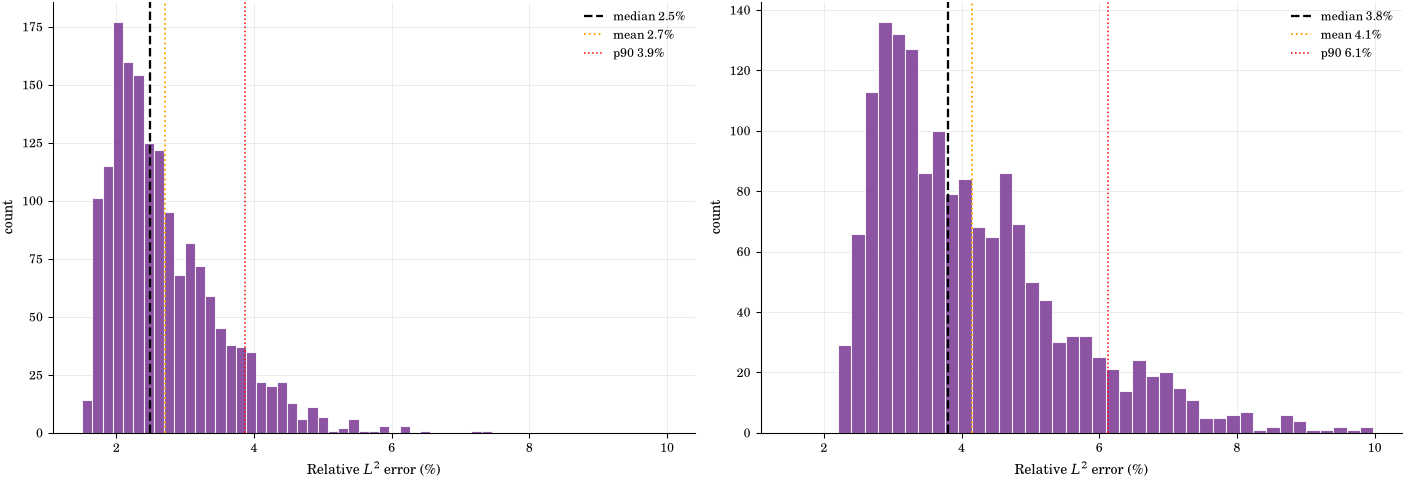

  ↳ article/images/dlrom_hist.pdf


PosixPath('/users/eleves-b/2023/keyvan.attarian/diffusion_ae/article/images/dlrom_hist.pdf')

In [10]:
# DL-ROM Nt=150 : histogrammes AE reconstruction (U->U) ET surrogate (theta->U).
from dl_rom.ckpt_utils import load_dlrom_from_ckpt

_AE_CKPT  = os.path.join(CKPT_DIR, 'dlrom_ld64_Nt150.ckpt')
_AE_CACHE = os.path.join(CACHE_DIR, 'dlrom_ae_recon_Nt150.npz')

def _eval_dlrom_ae(ae_ckpt, idx_list, device='cpu', batch_size=8):
    raw = torch.load(ae_ckpt, map_location='cpu', weights_only=False)
    U_mean = torch.as_tensor(raw['U_mean'], dtype=torch.float32, device=device)
    U_std  = torch.as_tensor(raw['U_std'],  dtype=torch.float32, device=device)
    ae = load_dlrom_from_ckpt(ae_ckpt, N=N, Nt=NT_FULL)[0].to(device).eval()
    out = []
    for s in tqdm(range(0, len(idx_list), batch_size), desc='DL-ROM AE recon', leave=False):
        batch = idx_list[s:s + batch_size]
        U  = torch.stack([torch.from_numpy(load_u(i)) for i in batch]).to(device)
        Un = (U - U_mean) / U_std
        with torch.no_grad():
            rec = ae(Un)
            rec = rec[0] if isinstance(rec, (tuple, list)) else rec
        Urec = rec * U_std + U_mean
        for j in range(len(batch)):
            d = torch.linalg.norm(U[j])
            out.append(float(torch.linalg.norm(Urec[j] - U[j]) / d * 100) if d > 0 else np.nan)
        if device == 'cuda': torch.cuda.empty_cache()
    ae.cpu(); del ae; gc.collect()
    return np.array(out)

# ── cache mtime ──────────────────────────────────────────────────────────────
if os.path.exists(_AE_CACHE) and os.path.exists(_AE_CKPT) and \
        float(np.load(_AE_CACHE)['mtime']) == os.path.getmtime(_AE_CKPT):
    l2_ae = np.load(_AE_CACHE)['l2rel']; print('[cache]   DL-ROM AE recon')
elif os.path.exists(_AE_CKPT):
    print('[compute] DL-ROM AE recon')
    l2_ae = _eval_dlrom_ae(_AE_CKPT, test_idx, device=device)
    np.savez(_AE_CACHE, l2rel=l2_ae, mtime=np.float64(os.path.getmtime(_AE_CKPT)))
else:
    l2_ae = None; print('DL-ROM AE checkpoint absent:', _AE_CKPT)

# ── surrogate l2 (depuis results) ────────────────────────────────────────────
_dl = [n for n in results if results[n]['model_type'] == 'DLROMModel'
       and results[n]['Nt_eff'] == NT_FULL] if results else []
l2_surr = results[_dl[0]]['l2_grid'] if _dl else None

panels = [(l2_ae, 'AE reconstruction ($U\\to U$)'),
          (l2_surr, 'surrogate ($\\theta\\to U$)')]
fig, axs = plt.subplots(1, 2, figsize=(13, 4.6), sharex=True)
for ax, (l2, sub) in zip(axs, panels):
    if l2 is None:
        ax.set_visible(False); continue
    med, mean, p90 = np.nanmedian(l2), np.nanmean(l2), np.nanpercentile(l2, 90)
    ax.hist(l2[~np.isnan(l2)], bins=40, color=PALETTE['DLROMModel'], edgecolor='white', alpha=0.88)
    ax.axvline(med,  color='black',  ls='--', lw=1.5, label=f'median {med:.1f}%')
    ax.axvline(mean, color='orange', ls=':',  lw=1.2, label=f'mean {mean:.1f}%')
    ax.axvline(p90,  color='red',    ls=':',  lw=1.0, label=f'p90 {p90:.1f}%')
    ax.set_xlabel('Relative $L^2$ error (%)'); ax.set_ylabel('count')
    ax.legend()
fig.tight_layout();
plt.show()
figstyle.save("hist")


## 8. Surrogate size

$N_{\mathrm{surr}} = N_{\mathrm{trunk}} + K \cdot N_{\mathrm{head}}$ counts the surrogate MLP alone, excluding the decoder: about 23.5M at $N_t = 150$ for DL-ROM against 3.5M at $K = 16$ for the Laplace pipelines.


In [11]:
def _compression(r: dict) -> float:
    return NT_FULL / r['n_heads']

if results:
    print(f"{'checkpoint':<40} {'famille':<8} {'κ':>3} {'Nt_eff':>6} {'têtes':>6} "
          f"{'N_surr(M)':>10} {'compr.×':>8}")
    print('-' * 90)
    for name, r in sorted(results.items(), key=lambda kv: -kv[1]['n_heads']):
        print(f"{name:<40} {_family(r['model_type']):<8} {r['kappa']:>3} {r['Nt_eff']:>6} "
              f"{r['n_heads']:>6} {r['n_surr']/1e6:>10.2f} {_compression(r):>8.1f}")
else:
    print('Pas de résultats — checkpoints absents (host GPU distant requis).')

checkpoint                               famille    κ Nt_eff  têtes  N_surr(M)  compr.×
------------------------------------------------------------------------------------------
DLROMModel__dlrom_ld64_Nt150__t4h2       DL-ROM     1    150    150      23.50      1.0
DLROMModel__dlrom_ld64_Nt75__t4h2        DL-ROM     2     75     75      12.15      2.0
DLROMModel__dlrom_ld64_Nt50__t4h2        DL-ROM     3     50     50       8.36      3.0
DLROMModel__dlrom_ld64_Nt30__t4h2        DL-ROM     5     30     30       5.33      5.0
LLAEModel__llae_ld64_K16_g0.0_ll__t4h2   LLAE       1    150     16       3.48      9.4
LLAEModel__llae_ld64_K16_g0.01__t4h2     LLAE       1    150     16       3.48      9.4
SLAEModel__slae_ld64_K16_g0.0_ol__t4h2   SLAE       1    150     16       3.22      9.4
SLAEModel__slae_ld64_K16_g0.01__t4h2     SLAE       1    150     16       3.22      9.4
DLROMModel__dlrom_ld64_Nt15__t4h2        DL-ROM    10     15     15       3.06     10.0


## 9. Inference cost

Latency, FLOPs, peak memory and energy at batch size 1, measured by `notebooks/benchmark.py`. The axes need not agree — see Dehghani et al. (2022) on the efficiency misnomer — which is why all four are reported.


In [12]:
import benchmark   # methodologie commune a tous les notebooks

bench = {}

for name, ckpt_path in tqdm(ckpt_paths.items(), desc='inference benchmark'):
    if name not in results:
        continue
    try:
        pipe = InferencePipeline.from_checkpoint(ckpt_path, device=device)
        tmean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
        tstd  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)
        th1 = (torch.tensor(theta_np[test_idx[:1]], dtype=torch.float32, device=device) - tmean) / tstd

        def gen1():
            with torch.no_grad():
                pipe.model.generate(th1)

        bench[name] = benchmark.measure(gen1, device, name=name)

        pipe.model.cpu(); del pipe
        if device == 'cuda':
            torch.cuda.empty_cache()
        gc.collect()
    except Exception as e:
        print(f'{name}  ERROR: {e}')

print('\nDone.')


inference benchmark:   0%|          | 0/9 [00:00<?, ?it/s]

/tmp/ipykernel_583903/2549316423.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tmean = torch.tensor(pipe.ckpt['theta_mean'], dtype=torch.float32, device=device)
/tmp/ipykernel_583903/2549316423.py:11: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  tstd  = torch.tensor(pipe.ckpt['theta_std'],  dtype=torch.float32, device=device)


DLROMModel__dlrom_ld64_Nt150__t4h2            lat=   31.4±  1.0 ms  flops=  48.3 G  mem=   927 MB  E=2888.8 mJ


inference benchmark:  11%|█         | 1/9 [00:04<00:37,  4.63s/it]

inference benchmark:  22%|██▏       | 2/9 [00:07<00:25,  3.68s/it]

...

inference benchmark:  89%|████████▉ | 8/9 [00:23<00:02,  2.90s/it]

SLAEModel__slae_ld64_K16_g0.0_ol__t4h2        lat=   15.6±  0.3 ms  flops=  30.3 G  mem=   235 MB  E=1669.7 mJ


inference benchmark: 100%|██████████| 9/9 [00:26<00:00,  2.85s/it]

inference benchmark: 100%|██████████| 9/9 [00:26<00:00,  2.96s/it]

SLAEModel__slae_ld64_K16_g0.01__t4h2          lat=   15.7±  0.3 ms  flops=  30.3 G  mem=   235 MB  E=1684.1 mJ

Done.


## 10. Benchmark — latency (bar chart)

Per-sample latency at `bs=1` (10 warm-up / 50 CUDA-Event runs), DL-ROM at $N_t=150$.

checkpoint                                       lat (ms)       ±   FLOPs (G)   mem (MB)    E (mJ)
--------------------------------------------------------------------------------------------------
SLAE (optimized contour)                             15.6     0.3        30.3        235    1669.7
SLAE (fixed contour)                                 15.7     0.3        30.3        235    1684.1
LLAE (fixed contour)                                 22.7     3.4        48.2        622    2877.7
LLAE (learned poles)                                 23.8     3.7        48.2        621    2974.7
DL-ROM $N_t$=150                                     31.4     1.0        48.3        927    2888.8


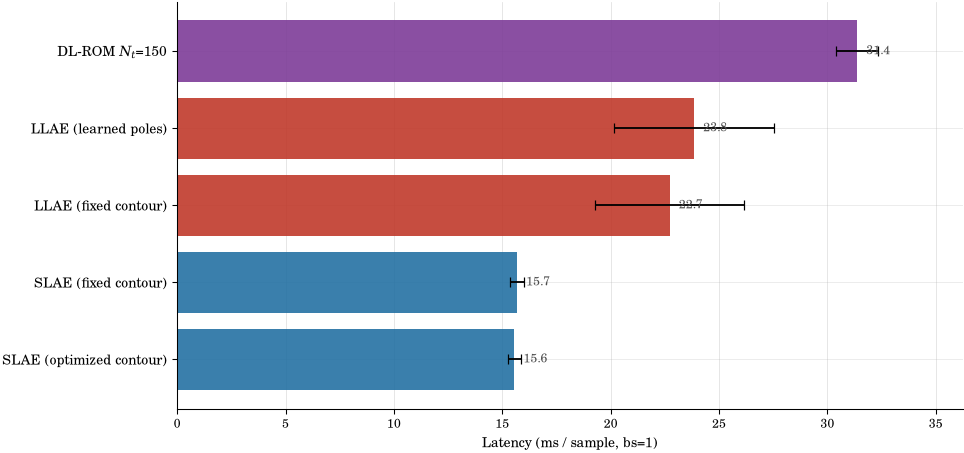

  ↳ article/images/dlrom_bench_latency.pdf


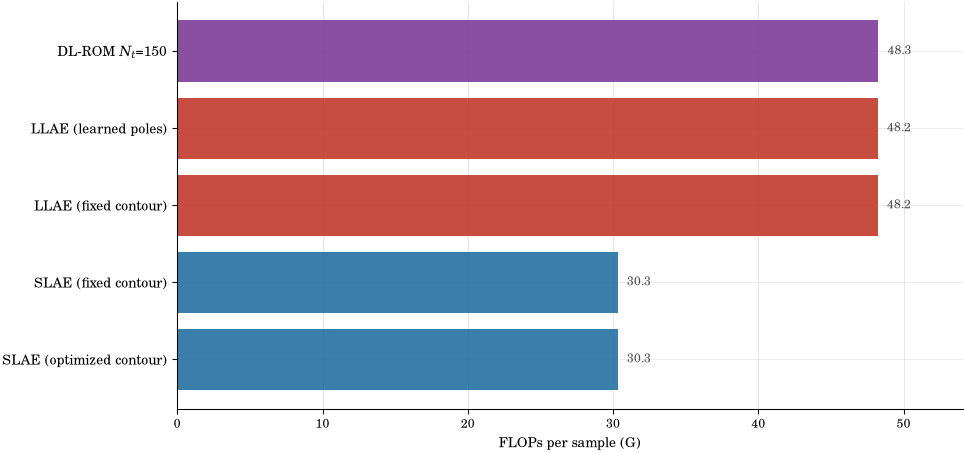

  ↳ article/images/dlrom_bench_flops.pdf


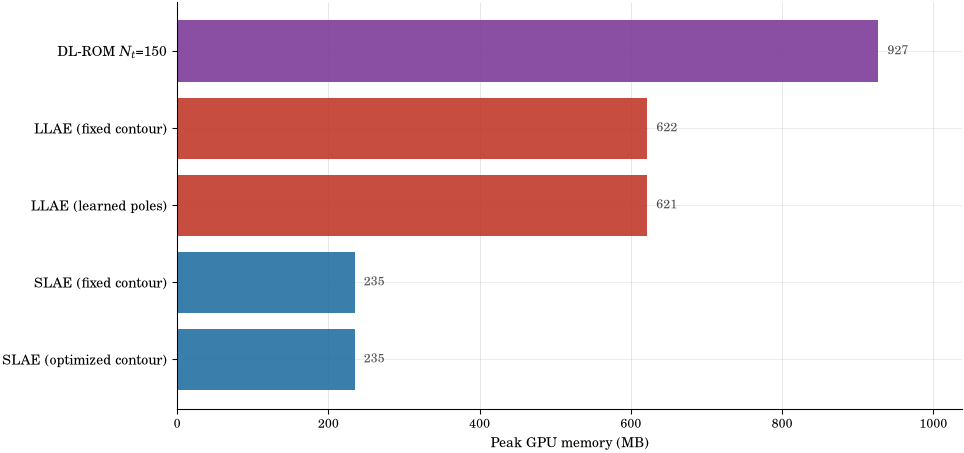

  ↳ article/images/dlrom_bench_memory.pdf


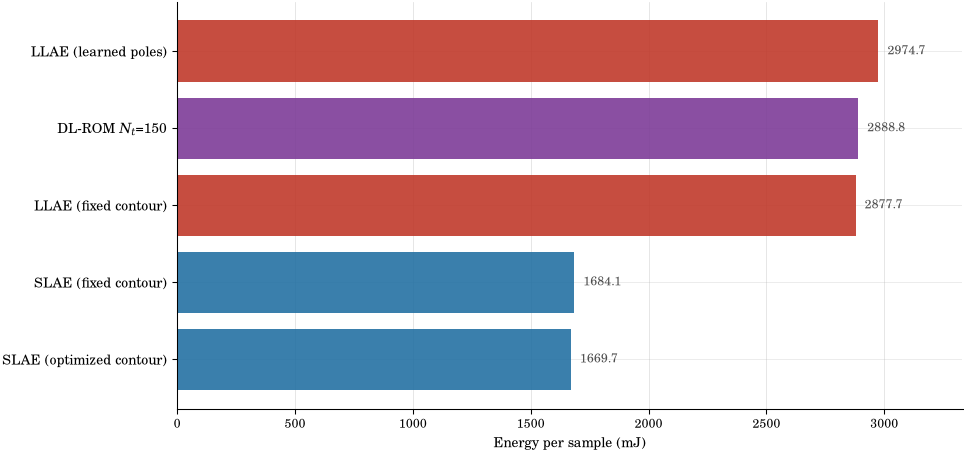

  ↳ article/images/dlrom_bench_energy.pdf


In [13]:
# One figure per metric.
if bench and results:
    _names = [n for n in _pointwise_names(results) if n in bench]
    _b = {n: bench[n] for n in _names}

    def _bench_label(t):
        return _mk(t)['tag']

    def _bench_color(t):
        return PALETTE.get(results[t]['model_type'], 'gray')

    benchmark.table(_b, label_of=_bench_label)
    benchmark.figures(_b, label_of=_bench_label, color_of=_bench_color, device=device)
else:
    print('No bench — skipped.')


## 11. Summary table

One row per DL-ROM resolution, with the Laplace references below. Output resolution is carried by the $N_t$ column.


In [14]:
if results:
    def _row(name, r):
        g    = r['l2_grid']
        lat  = bench.get(name, {}).get('lat_med', np.nan)
        return dict(
            fam    = _family(r['model_type']),
            Nt     = r['Nt_eff'],
            kappa  = r['kappa'],
            compr  = _compression(r),
            surrM  = r['n_surr'] / 1e6,
            lat    = lat,
            g_med  = np.nanmedian(g),  g_p90 = np.nanpercentile(g, 90),
        )

    dl_rows  = [(n, _row(n, r)) for n, r in results.items() if r['model_type'] == 'DLROMModel']
    lap_rows = [(n, _row(n, r)) for n, r in results.items()
                if r['model_type'] in ('LLAEModel', 'SLAEModel')]
    dl_rows.sort(key=lambda kv: -kv[1]['Nt'])
    lap_rows.sort(key=lambda kv: kv[1]['fam'])

    hdr = (f"{'modèle':<14}{'Nt':>4}{'κ':>4}{'compr×':>8}{'N_surr(M)':>11}"
           f"{'lat(ms)':>9}{'grille med':>12}{'grille p90':>12}")
    print(hdr); print('-' * len(hdr))
    def _pr(tag, d):
        lat = f"{d['lat']:>9.1f}" if np.isfinite(d['lat']) else f"{'—':>9}"
        print(f"{tag:<14}{d['Nt']:>4}{d['kappa']:>4}{d['compr']:>8.1f}{d['surrM']:>11.2f}"
              f"{lat}{d['g_med']:>11.2f}%{d['g_p90']:>11.2f}%")
    for _, d in dl_rows:
        _pr(f"DL-ROM Nt{d['Nt']}", d)
    print('-' * len(hdr))
    for _, d in lap_rows:
        _pr(f"{d['fam']}-K16", d)
    print(f"{'POD surrogate':<14}{'—':>4}{'—':>4}{'—':>8}{'—':>11}{'—':>9}"
          f"{POD_REF_MEDIAN:>11.2f}%{'—':>11}")

    # DataFrame optionnel (si pandas dispo)
    try:
        import pandas as pd
        rows = ([dict(model=f"DL-ROM Nt{d['Nt']}", **d) for _, d in dl_rows] +
                [dict(model=f"{d['fam']}-K16", **d) for _, d in lap_rows])
        df = pd.DataFrame(rows)[['model', 'Nt', 'kappa', 'compr', 'surrM', 'lat',
                                 'g_med', 'g_p90']]
        display(df.round(2))
    except Exception:
        pass
else:
    print('Pas de résultats — table sautée.')

modèle          Nt   κ  compr×  N_surr(M)  lat(ms)  grille med  grille p90
--------------------------------------------------------------------------
DL-ROM Nt150   150   1     1.0      23.50     31.4       3.80%       6.12%
DL-ROM Nt75     75   2     2.0      12.15     15.8       3.97%       6.40%
DL-ROM Nt50     50   3     3.0       8.36     10.6       3.84%       6.19%
DL-ROM Nt30     30   5     5.0       5.33      6.7       3.86%       6.30%
DL-ROM Nt15     15  10    10.0       3.06      3.8       3.73%       5.98%
--------------------------------------------------------------------------
LLAE-K16       150   1     9.4       3.48     23.8       4.63%       7.65%
LLAE-K16       150   1     9.4       3.48     22.7       4.06%       6.48%
SLAE-K16       150   1     9.4       3.22     15.6       7.46%      13.38%
SLAE-K16       150   1     9.4       3.22     15.7       7.60%       9.50%
POD surrogate    —   —       —          —        —       8.91%          —
